In [ ]:
# ==============================================================================
# 1. IMPORT LIBRARIES 
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv
from pathlib import Path

load_dotenv(dotenv_path=Path('etl/.env'))

warnings.filterwarnings('ignore')

# Modelos de scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
)

# Los 8 Modelos a comparar
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Preprocesamiento
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Todas las librerías cargadas correctamente.")

✅ Todas las librerías cargadas correctamente.


In [ ]:
# Cargar variables de entorno
load_dotenv()
user = os.getenv('DB_USER')
password = os.getenv('DB_PASSWORD')
host = os.getenv('DB_HOST')
port = os.getenv('DB_PORT')
db = os.getenv('DB_NAME')

# Conectar y extraer
engine = create_engine(f'postgresql://{user}:{password}@{host}:{port}/{db}')
query = "SELECT * FROM dw_inventario_predictivo"
df = pd.read_sql(query, engine)

print("============================================================")
print("CARGANDO DATASET DE QUIEBRES DE STOCK (MERCADOS LA COLINA)")
print("============================================================")
print(f"Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")
print("\nDistribución de la variable target (quiebre_stock):")
print(df['quiebre_stock'].value_counts())
print(f"\nTasa de quiebre global: {(df['quiebre_stock'].mean() * 100):.2f}%")

📊 CARGANDO DATASET DE QUIEBRES DE STOCK (MERCADOS LA COLINA)
📏 Dimensiones: 14258 filas × 18 columnas

🎯 Distribución de la variable target (quiebre_stock):
quiebre_stock
1    7796
0    6462
Name: count, dtype: int64

📈 Tasa de quiebre global: 54.68%


In [ ]:
# 1. Separar features (X) y target (y)
# Eliminamos IDs y Fechas porque causan Data Leakage (sobreajuste)
columnas_a_eliminar = ['id_producto_tienda_semana', 'inicio_semana', 'quiebre_stock']
X = df.drop(columns=columnas_a_eliminar, errors='ignore')
y = df['quiebre_stock']

# 2. Convertir variables categóricas a números (One-Hot Encoding)
columnas_texto = X.select_dtypes(include=['object']).columns.tolist()
if columnas_texto:
    X = pd.get_dummies(X, columns=columnas_texto, drop_first=True)

# 3. División Train/Test (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 4. Escalado (Vital para Regresión Logística, KNN y SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Dataset listo: {X_train.shape[0]} registros para entrenar, {X_test.shape[0]} para probar.")
print(f"Total de Features (Variables predictoras): {X.shape[1]}")

✅ Dataset listo: 11406 registros para entrenar, 2852 para probar.
📊 Total de Features (Variables predictoras): 30


In [ ]:
# Calcular ratio de desbalance para ayudar a los modelos de árboles
ratio = (y_train == 0).sum() / (y_train == 1).sum()

modelos = {
    '1. Regresión Logística': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    '2. Árbol de Decisión': DecisionTreeClassifier(max_depth=8, class_weight='balanced', random_state=42),
    '3. Random Forest': RandomForestClassifier(n_estimators=300, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1),
    '4. XGBoost': XGBClassifier(n_estimators=500, max_depth=5, learning_rate=0.05, scale_pos_weight=ratio, random_state=42, eval_metric='auc'),
    '5. LightGBM': LGBMClassifier(n_estimators=500, max_depth=5, learning_rate=0.05, scale_pos_weight=ratio, random_state=42, verbose=-1),
    '6. KNN (k=10)': KNeighborsClassifier(n_neighbors=10, weights='distance', n_jobs=-1),
    '7. Naive Bayes': GaussianNB(),
    '8. SVM (RBF)': SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42)
}

print(f"{len(modelos)} modelos configurados y listos para competir.")

✅ 8 modelos configurados y listos para competir.


In [ ]:
resultados = []

print("=" * 80)
print("ENTRENANDO Y EVALUANDO TODOS LOS MODELOS")
print("=" * 80)

for nombre, modelo in modelos.items():
    print(f"\nEntrenando {nombre}...")
    inicio = time.time()
    
    try:
        # Usar datos escalados para modelos matemáticos espaciales
        if nombre in ['1. Regresión Logística', '6. KNN (k=10)', '8. SVM (RBF)']:
            X_tr, X_te = X_train_scaled, X_test_scaled
        else:
            X_tr, X_te = X_train, X_test
        
        # Entrenar
        modelo.fit(X_tr, y_train)
        
        # Predecir
        y_pred = modelo.predict(X_te)
        y_pred_proba = modelo.predict_proba(X_te)[:, 1]
        
        # Métricas
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_pred_proba)
        
        # Cross-validation (5-fold)
        cv_scores = cross_val_score(modelo, X_tr, y_train, cv=5, scoring='roc_auc')
        cv_mean = cv_scores.mean()
        cv_std = cv_scores.std()
        
        tiempo = time.time() - inicio
        
        resultados.append({
            'Modelo': nombre, 'Accuracy': accuracy, 'Precision': precision, 
            'Recall': recall, 'F1-Score': f1, 'ROC-AUC': auc, 
            'CV ROC-AUC': cv_mean, 'CV Std': cv_std, 'Tiempo (s)': tiempo
        })
        
        print(f"   Accuracy: {accuracy:.3f} | AUC: {auc:.3f} | CV-AUC: {cv_mean:.3f}±{cv_std:.3f}")
        print(f"   Tiempo: {tiempo:.2f}s")
        
    except Exception as e:
        print(f"   ❌ Error: {e}")

df_resultados = pd.DataFrame(resultados).sort_values('ROC-AUC', ascending=False)
print("=" * 100)
print("TABLA COMPARATIVA DE MODELOS (Ordenada por ROC-AUC)")
print("=" * 100)
display(df_resultados)

🤖 ENTRENANDO Y EVALUANDO TODOS LOS MODELOS

🔄 Entrenando 1. Regresión Logística...
   ✅ Accuracy: 0.650 | AUC: 0.706 | CV-AUC: 0.713±0.010
   ⏱️ Tiempo: 0.21s

🔄 Entrenando 2. Árbol de Decisión...
   ✅ Accuracy: 0.635 | AUC: 0.676 | CV-AUC: 0.665±0.012
   ⏱️ Tiempo: 0.19s

🔄 Entrenando 3. Random Forest...
   ✅ Accuracy: 0.640 | AUC: 0.694 | CV-AUC: 0.696±0.006
   ⏱️ Tiempo: 3.75s

🔄 Entrenando 4. XGBoost...
   ✅ Accuracy: 0.635 | AUC: 0.683 | CV-AUC: 0.684±0.006
   ⏱️ Tiempo: 6.08s

🔄 Entrenando 5. LightGBM...
   ✅ Accuracy: 0.637 | AUC: 0.686 | CV-AUC: 0.684±0.007
   ⏱️ Tiempo: 3.39s

🔄 Entrenando 6. KNN (k=10)...
   ✅ Accuracy: 0.610 | AUC: 0.646 | CV-AUC: 0.646±0.005
   ⏱️ Tiempo: 0.27s

🔄 Entrenando 7. Naive Bayes...
   ✅ Accuracy: 0.647 | AUC: 0.686 | CV-AUC: 0.688±0.006
   ⏱️ Tiempo: 0.07s

🔄 Entrenando 8. SVM (RBF)...
   ✅ Accuracy: 0.639 | AUC: 0.692 | CV-AUC: 0.694±0.009
   ⏱️ Tiempo: 85.09s
📊 TABLA COMPARATIVA DE MODELOS (Ordenada por ROC-AUC)


,Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC,CV ROC-AUC,CV Std,Tiempo (s)
0,1. Regresión Logística,0.649719,0.682292,0.672226,0.677221,0.705977,0.712930,0.009669,0.214092
2,3. Random Forest,0.639902,0.673177,0.663246,0.668174,0.694374,0.695608,0.006396,3.751462
7,8. SVM (RBF),0.638850,0.679079,0.643361,0.660738,0.691540,0.694021,0.009180,85.086349
6,7. Naive Bayes,0.647265,0.669945,0.699166,0.684244,0.686210,0.688322,0.005528,0.072797
4,5. LightGBM,0.637447,0.676530,0.645285,0.660538,0.685817,0.684266,0.007194,3.385549
3,4. XGBoost,0.635344,0.675694,0.640154,0.657444,0.683479,0.683648,0.006307,6.081805
1,2. Árbol de Decisión,0.634642,0.678893,0.629250,0.653129,0.675668,0.664641,0.011889,0.190794
5,6. KNN (k=10),0.610449,0.630994,0.692110,0.660141,0.646013,0.645769,0.005345,0.268310


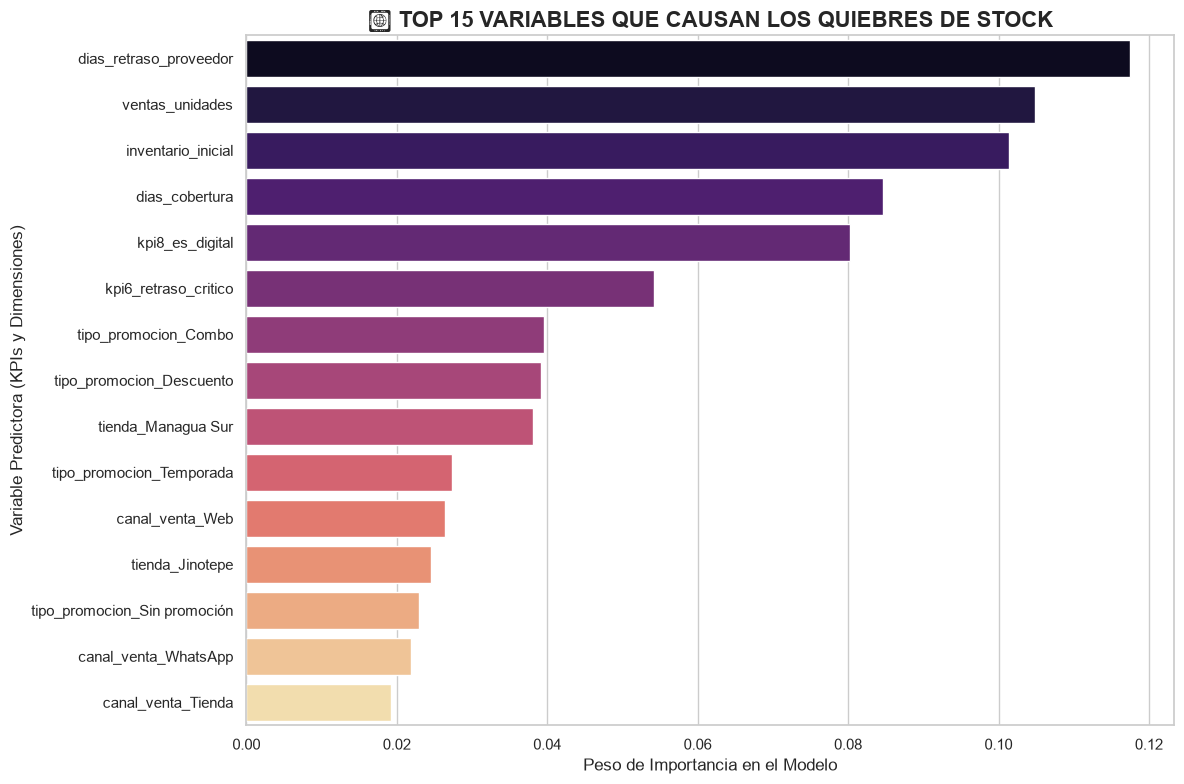

💡 CONCLUSIÓN DE NEGOCIO:
La variable que más detona los quiebres de stock es: 'dias_retraso_proveedor'.
Esto demuestra que la Minería de Datos va más allá del BI tradicional, encontrando la verdadera causa raíz.


In [ ]:
# Vamos a usar el Random Forest que quedó en 2do lugar (es excelente para ver la importancia de variables)
modelo_arbol = modelos['3. Random Forest'] 

# Obtener el peso (importancia) de cada variable
importancias = modelo_arbol.feature_importances_
features = X.columns

# Crear un DataFrame para ordenarlas
df_importancia = pd.DataFrame({
    'Variable': features,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False)

# Graficar
plt.figure(figsize=(12, 8))
sns.barplot(x='Importancia', y='Variable', data=df_importancia.head(15), palette='magma')
plt.title('TOP 15 VARIABLES QUE CAUSAN LOS QUIEBRES DE STOCK', fontsize=16, fontweight='bold')
plt.xlabel('Peso de Importancia en el Modelo', fontsize=12)
plt.ylabel('Variable Predictora (KPIs y Dimensiones)', fontsize=12)
plt.tight_layout()
plt.show()

# Imprimir la conclusión
print("CONCLUSIÓN DE NEGOCIO:")
print(f"La variable que más detona los quiebres de stock es: '{df_importancia.iloc[0]['Variable']}'.")
print("Esto demuestra que la Minería de Datos va más allá del BI tradicional, encontrando la verdadera causa raíz.")